### Understanding Conjugate Priors

In Bayesian statistics, a prior distribution $\pi(\theta)$ is *conjugate* to the likelihood function $L(X | \theta)$ if the resulting posterior distribution $\pi(\theta | X)$ belongs to the same probability distribution family as the prior distribution.

This property simplifies Bayesian inference significantly because the posterior distribution has a known functional form, making it easier to analyze and compute posterior statistics (like mean, variance, credible intervals).

### Problem: Beta-Bernoulli Conjugacy

Let's consider a common example: a Bernoulli likelihood with a Beta prior.

*   **Parameter of Interest**: $p$, the probability of success in a Bernoulli trial ($0 \le p \le 1$).
*   **Prior Distribution**: We assume $p \sim \text{Beta}(a, b)$. The Beta distribution is a flexible distribution defined on the interval $[0, 1]$ and is often used for probabilities.
    *   Probability Density Function (PDF): $\pi(p) = \frac{p^{a-1}(1-p)^{b-1}}{B(a,b)}$, where $B(a,b)$ is the Beta function.
    *   For proportionality, we write: $\pi(p) \propto p^{a-1}(1-p)^{b-1}$
*   **Likelihood Function**: We observe $n$ independent Bernoulli trials, $X_1, \dots, X_n$, where $X_i \sim \text{Bernoulli}(p)$. Let $S_n = \sum_{i=1}^n X_i$ be the number of successes.
    *   Likelihood: $L(X_1, \dots, X_n | p) = p^{S_n}(1-p)^{n-S_n}$

##### Deriving the Posterior

By Bayes' Theorem $\pi(p | X_1, \dots, X_n) \propto L(X_1, \dots, X_n | p) \cdot \pi(p)$. Substituting the proportional forms $\pi(p | X_1, \dots, X_n) \propto (p^{S_n}(1-p)^{n-S_n}) \cdot (p^{a-1}(1-p)^{b-1})$. Combining terms with the same base $\pi(p | X_1, \dots, X_n) \propto p^{(S_n + a - 1)}(1-p)^{(n - S_n + b - 1)}$. This is the kernel of another Beta distribution!  Specifically, the posterior distribution is
- $\text{Beta}(a', b')$, where $a' = a + S_n$, $b' = b + n - S_n$.

Thus, the Beta distribution is a conjugate prior for the Bernoulli likelihood, as the posterior is also a Beta distribution.

True p: 0.7
Observations: [1 0 0 1 1 1 1 0 1 0]
Number of trials (n): 10
Number of successes (S_n): 6

Prior Beta parameters: a=2, b=2
Posterior Beta parameters: a'=8, b'=6


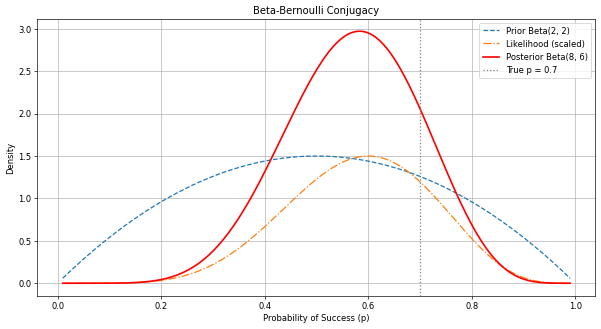

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Prior Parameters
a_prior = 2 ; b_prior = 2

# Simulate Data (Bernoulli Observations)
true_p = 0.7 # The true probability of success
n_observations = 10 # Number of Bernoulli trials

# Generate random Bernoulli observations
np.random.seed(42) # for reproducibility
observations = np.random.binomial(n=1, p=true_p, size=n_observations)

# Calculate number of successes
num_successes = np.sum(observations)
num_failures = n_observations - num_successes

# Calculate Posterior Parameters
a_posterior = a_prior + num_successes
b_posterior = b_prior + num_failures

# Visualize Prior, Likelihood, and Posterior
p_values = np.linspace(0.01, 0.99, 200)

# Prior PDF
prior_pdf = beta.pdf(p_values, a_prior, b_prior)

# Likelihood (proportional to p^S_n * (1-p)^(n-S_n))
# For plotting purposes, we can normalize it to fit on the same scale, though mathematically it's not a PDF
likelihood = p_values**num_successes * (1 - p_values)**num_failures
likelihood = likelihood / np.max(likelihood) * np.max(prior_pdf) #scale for plot

# Posterior PDF
posterior_pdf = beta.pdf(p_values, a_posterior, b_posterior)

### (a) Exponential Likelihood with Exponential Prior

**Goal**: Derive the posterior distribution for the rate parameter $\lambda$ when both the likelihood and the prior are Exponential distributions.

Given: 1.**Prior Distribution**: $\lambda \sim \text{Exp}(a)$ (Exponential with rate $a > 0$). The PDF is $\pi(\lambda) = a e^{-a\lambda}$ for $\lambda \ge 0$. For proportionality, we write: $\pi(\lambda) \propto e^{-a\lambda}$. 2.**Likelihood Function**: We observe $n$ independent Exponential trials, $X_1, \dots, X_n$, where $X_i \sim \text{Exp}(\lambda)$. Let $S_n = \sum_{i=1}^n X_i$ be the sum of observations. The PDF for a single observation is $f(X_i | \lambda) = \lambda e^{-\lambda X_i}$.

Approach: 1.) Define the proportional forms of the prior and likelihood. 2.) Apply Bayes' theorem to find the proportional form of the posterior: $\pi(\lambda | X_1, \dots, X_n) \propto L(X_1, \dots, X_n | \lambda) \cdot \pi(\lambda)$. 3.) Identify the resulting posterior distribution by comparing its form to known probability distributions.

The Likelihood: For $n$ i.i.d. observations $X_1, \dots, X_n$, where each $X_i \sim \text{Exp}(\lambda)$, the joint likelihood function is the product of the individual PDFs: $L(X_1, \dots, X_n | \lambda) = \prod_{i=1}^n (\lambda e^{-\lambda X_i}) = \lambda^n e^{-\lambda X_1} e^{-\lambda X_2} \cdots e^{-\lambda X_n} = \lambda^n e^{-\lambda (X_1 + X_2 + \dots + X_n)}$

Let $S_n = \sum_{i=1}^n X_i$. Then the likelihood function is given by $L(X_1, \dots, X_n | \lambda) = \lambda^n e^{-\lambda S_n}$. For proportionality in Bayesian inference, we consider this form directly.

#### Deriving the Posterior

By Bayes' Theorem $\pi(\lambda | X_1, \dots, X_n) \propto L(X_1, \dots, X_n | \lambda) \cdot \pi(\lambda)$

Substituting the proportional forms of the prior and likelihood $\pi(\lambda | X_1, \dots, X_n) \propto (\lambda^n e^{-\lambda S_n}) \cdot (e^{-a\lambda})$. Combining the exponential terms $\pi(\lambda | X_1, \dots, X_n) \propto \lambda^n e^{-(a + S_n)\lambda}$.

This form is the kernel of a Gamma distribution. The standard parameterization of the Gamma distribution (with shape $k$ and rate $\beta$) has a PDF proportional to $x^{k-1} e^{-\beta x}$. Comparing our derived posterior kernel $\lambda^n e^{-(a + S_n)\lambda}$ with the Gamma PDF kernel $x^{k-1} e^{-\beta x}$: **Shape parameter ($k$)**, $k - 1 = n \implies k = n + 1$, and **Rate parameter ($\beta$)**, $\beta = a + S_n$. Thus, the posterior distribution for $\lambda$ is
- $\text{Gamma}(k = n + 1, \beta = a + S_n)$.

Since the prior is an Exponential distribution (which is a special case of the Gamma distribution with shape parameter 1) and the posterior is also a Gamma distribution, the Exponential distribution is a conjugate prior for the rate parameter of an Exponential likelihood. Your previous assertion that it's not a conjugate prior is incorrect.

#### Posterior Statistics

For a Gamma distribution with shape $k$ and rate $\beta$:

- Mean: $E[\lambda] = \frac{k}{\beta} = \frac{n+1}{a + S_n}$, Variance: $Var[\lambda] = \frac{k}{\beta^2} = \frac{n+1}{(a + S_n)^2}$, and Mode: $\frac{k-1}{\beta} = \frac{n}{a + S_n}$ (for $k > 1$, i.e., $n > 0$)

True lambda (rate): 2.0
Observations: [0.23 1.51 0.66 0.46 0.08 0.08 0.03 1.01 0.46 0.62]
Number of trials (n): 10
Sum of observations (S_n): 5.13

Prior Exponential rate parameter (a): 0.5
Posterior Gamma parameters: shape k=11, rate beta=5.63


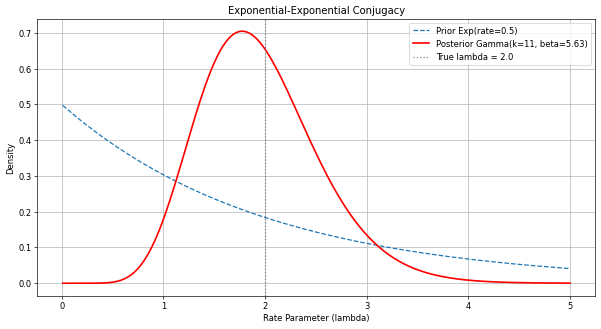

In [5]:
# Prior Parameters (Exponential)
a_prior = 0.5  # Rate parameter for the Exponential prior

# Simulate Data (Exponential Observations)
true_lambda = 2.0  # The true rate parameter of the data-generating process
n_observations = 10  # Number of Exponential trials

# Generate random Exponential observations
np.random.seed(42)  # for reproducibility
# scipy.stats.expon uses scale=1/rate, so rate=true_lambda means scale=1/true_lambda
observations = expon.rvs(scale=1/true_lambda, size=n_observations)

# Calculate sum of observations
sum_observations = np.sum(observations)

# Calculate Posterior Parameters (Gamma)
# Posterior shape k = n + 1
k_posterior = n_observations + 1
# Posterior rate beta = a + S_n
beta_posterior = a_prior + sum_observations

# Visualize Prior, Posterior
lambda_values = np.linspace(0.01, 5.0, 200)

# Prior PDF (Exponential)
# scipy.stats.expon uses scale=1/rate, so rate=a_prior means scale=1/a_prior
prior_pdf = expon.pdf(lambda_values, scale=1/a_prior)

# Posterior PDF (Gamma)
# scipy.stats.gamma uses shape=k and scale=1/rate
posterior_pdf = gamma.pdf(lambda_values, a=k_posterior, scale=1/beta_posterior)

#### Summary of Exponential-Exponential Conjugacy

In this example, we demonstrated the conjugate relationship between an Exponential prior and an Exponential likelihood.

- **Prior**: We started with an Exponential prior for the rate parameter $\lambda$ with $a_prior = 0.5$.
- **Data Simulation**: We simulated 10 observations from an Exponential distribution with a $true_lambda = 2.0$. The sum of these observations was $S_n = 5.13$.
- **Posterior**: After incorporating the observed data, the posterior distribution for $\lambda$ became a Gamma distribution with parameters $shape k = n + 1 = 11$ and $rate beta = a_prior + S_n = 0.5 + 5.13 = 5.63$.

The plot clearly illustrates this update:
- The **Prior dashed line** shows our initial, broader belief about $\lambda$.
- The **Posterior (solid red line)** is significantly more concentrated and has shifted towards the true_lambda = 2.0 (gray dotted line). This demonstrates how the observed data refines our uncertainty and provides a more precise estimate for the rate parameter.

### (b) Exponential Likelihood with Improper Uniform Prior

We continue with observations $X_1, \dots, X_n \sim \text{Exp}(\lambda)$ (i.i.d. Exponential with rate $\lambda$).
This time, we consider an **improper uniform prior** for $\lambda$:
$\pi(\lambda) \propto 1$ for $\lambda > 0$.

Our goal is to derive the posterior distribution $\pi(\lambda | X_1, \dots, X_n)$ and discuss its relationship with the previous case.

True lambda (rate): 2.0
Observations: [0.23 1.51 0.66 0.46 0.08 0.08 0.03 1.01 0.46 0.62]
Number of trials (n): 10
Sum of observations (S_n): 5.13

Prior Gamma parameters: shape a=2, scale b=1
Posterior Gamma parameters: shape k=12, rate beta=6.13


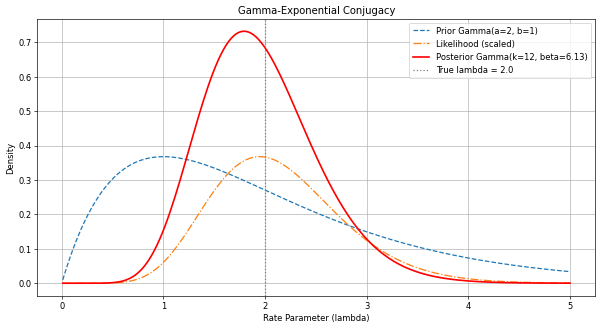

In [7]:
# Define Prior Parameters (Gamma)
a_prior = 2    # Shape parameter for the Gamma prior
b_prior = 1    # Scale parameter for the Gamma prior (rate = 1/b_prior)

# Define True Lambda
true_lambda = 2.0  # The true rate parameter of the data-generating process

# Simulate Data (Exponential Observations)
n_observations = 10  # Number of Exponential trials

np.random.seed(42)  # for reproducibility
# scipy.stats.expon uses scale=1/rate, so rate=true_lambda means scale=1/true_lambda
observations = expon.rvs(scale=1/true_lambda, size=n_observations)
sum_observations = np.sum(observations)

# Calculate Posterior Parameters (Gamma)
# Posterior shape k_posterior = a_prior + n
k_posterior = a_prior + n_observations
# Posterior rate beta_posterior = S_n + (1/b_prior)
beta_posterior_rate = sum_observations + (1/b_prior)

# Visualize Prior, Likelihood, and Posterior
lambda_values = np.linspace(0.01, 5.0, 200)

# Prior PDF (Gamma)
# scipy.stats.gamma uses shape=a and scale=scale
prior_pdf = gamma.pdf(lambda_values, a=a_prior, scale=b_prior)

# Likelihood (proportional to lambda^n * exp(-S_n * lambda))
# For plotting purposes, we can normalize it to fit on the same scale, though mathematically it's not a PDF
likelihood = lambda_values**n_observations * np.exp(-sum_observations * lambda_values)
# Scale likelihood to make it visible on the plot with prior/posterior
likelihood = likelihood / np.max(likelihood) * np.max(prior_pdf)

# Posterior PDF (Gamma)
# scipy.stats.gamma uses shape=a and scale=1/rate
posterior_pdf = gamma.pdf(lambda_values, a=k_posterior, scale=1/beta_posterior_rate)

#### Deriving the Posterior with an Improper Uniform Prior

1.  **Prior Distribution (proportional form)**:
$\pi(\lambda) \propto 1$ (for $\lambda > 0$)

2.  **Likelihood Function (from Problem 1a)**:
For $n$ i.i.d. observations $X_1, \dots, X_n$ from $\text{Exp}(\lambda)$, with $S_n = \sum_{i=1}^n X_i$, the likelihood is $L(X_1, \dots, X_n | \lambda) \propto \lambda^n e^{-\lambda S_n}$.

3.  **Posterior Distribution (proportional form)**:
According to Bayes' Theorem: $\pi(\lambda | X_1, \dots, X_n) \propto L(X_1, \dots, X_n | \lambda) \cdot \pi(\lambda)$. Substituting the proportional forms: $\pi(\lambda | X_1, \dots, X_n) \propto (\lambda^n e^{-\lambda S_n}) \cdot (1)$, $\pi(\lambda | X_1, \dots, X_n) \propto \lambda^n e^{-S_n\lambda}$

This form is the kernel of a Gamma distribution. Comparing it to the Gamma PDF kernel $x^{k-1} e^{-\beta x}$. **Shape parameter ($k$)**: $k - 1 = n \implies k = n + 1$, and **Rate parameter ($\beta$)**: $\beta = S_n$. Thus, the posterior distribution for $\lambda$ is
- $\text{Gamma}(k = n + 1, \beta = S_n)$.

#### Relationship between Prior and Posterior Distributions in (a) and (b)

In both Problem 1(a) (Exponential prior) and Problem 1(b) (improper uniform prior), the **posterior distribution for $\lambda$ is a Gamma distribution**.

*   **Problem 1(a) (Exponential Prior)**: Prior $\text{Exp}(a)$ (which is $\text{Gamma}(1, a)$), and Posterior $\text{Gamma}(n + 1, a + S_n)$

*   **Problem 1(b) (Improper Uniform Prior)**: Prior $\pi(\lambda) \propto 1$ (for $\lambda > 0$), and Posterior $\text{Gamma}(n + 1, S_n)$

Key Observations:
1.  **Conjugacy**: The Gamma distribution is the conjugate prior for the rate parameter of an Exponential likelihood. Both examples confirm this, as the posterior is always Gamma. The improper uniform prior, while not technically a proper Gamma distribution, acts as a "non-informative" prior that still leads to a posterior within the Gamma family, demonstrating a generalized form of conjugacy.
2.  **Influence of the Prior**: The parameters of the prior directly influence the parameters of the posterior.
    *   The shape parameter of the posterior is consistently $n+1$, primarily driven by the number of observations ($n$) and the $\lambda^n$ term in the likelihood.
    *   The rate parameter of the posterior changes: in (a), it's $a + S_n$, incorporating the prior's rate $a$. In (b), with the uniform prior, it effectively assumes $a=0$, resulting in a posterior rate of $S_n$. This shows how a non-informative prior (like the uniform) allows the data ($S_n$) to predominantly shape the posterior's rate parameter.
3.  **Proper vs. Improper Priors**: Even with an improper prior in (b), we obtained a proper posterior distribution (a Gamma distribution has finite integral). This is a desirable outcome, indicating that the data provided enough information to "regularize" the prior. The likelihood function, which is always a proper function of the observed data, acts to constrain the parameter space. When multiplied by an improper prior, if the likelihood is sufficiently concentrated, it can dominate the prior's flat or unbounded nature, resulting in a posterior distribution that integrates to a finite value, hence being proper and normalizable.

### (c): Gamma Prior with Exponential Likelihood

We continue with observations $X_1, \dots, X_n \sim \text{Exp}(\lambda)$ (i.i.d. Exponential with rate $\lambda$).

This time, we consider a **Gamma prior** for $\lambda$:
$\pi(\lambda) \sim \text{Gamma}(a, b)$, where $a$ is the shape parameter and $b$ is the scale parameter (so the rate is $1/b$).

**Goal**: Derive the posterior distribution for the rate parameter $\lambda$.

**Given**: 1.**Prior Distribution**: $\lambda \sim \text{Gamma}(a, b)$. Probability Density Function (PDF): $\pi(\lambda) = \frac{1}{\Gamma(a)b^a} \lambda^{a-1} e^{-\lambda/b}$ for $\lambda \ge 0$. For proportionality, we write: $\pi(\lambda) \propto \lambda^{a-1} e^{-\lambda/b}$. 2.**Likelihood Function**: We observe $n$ independent Exponential trials, $X_1, \dots, X_n$, where $X_i \sim \text{Exp}(\lambda)$. Let $S_n = \sum_{i=1}^n X_i$. From previous derivations, the likelihood is: $L(X_1, \dots, X_n | \lambda) \propto \lambda^n e^{-\lambda S_n}$

#### Deriving the Posterior

By Bayes' Theorem $\pi(\lambda | X_1, \dots, X_n) \propto L(X_1, \dots, X_n | \lambda) \cdot \pi(\lambda)$. Substituting the proportional forms of the prior and likelihood $\pi(\lambda | X_1, \dots, X_n) \propto (\lambda^n e^{-\lambda S_n}) \cdot (\lambda^{a-1} e^{-\lambda/b})$. Combining terms with the same base $\pi(\lambda | X_1, \dots, X_n) \propto \lambda^{(n + a - 1)} e^{- (S_n + 1/b) \lambda}$. This form is the kernel of a Gamma distribution. The standard parameterization of the Gamma distribution (with shape $k$ and rate $\beta$) has a PDF proportional to $x^{k-1} e^{-\beta x}$. Comparing our derived posterior kernel $\lambda^{(a+n)-1} e^{- (S_n + 1/b) \lambda}$ with the Gamma PDF kernel $x^{k-1} e^{-\beta x}$. **Shape parameter ($k_{posterior}$)** $k_{posterior} - 1 = a + n - 1 \implies k_{posterior} = a + n$, and **Rate parameter ($\beta_{posterior}$)** $\beta_{posterior} = S_n + \frac{1}{b}$. Thus, the posterior distribution for $\lambda$ is
- $\text{Gamma}(k_{posterior} = a + n, \beta_{posterior} = S_n + \frac{1}{b})$.

Since the prior is a Gamma distribution and the posterior is also a Gamma distribution, the Gamma distribution is a conjugate prior for the rate parameter of an Exponential likelihood.

### Problem Set: Bayesian and Frequentist Inference

We explore the intersection of Bayesian and frequentist inference. Let $X_1, \dots, X_n \sim \text{iid } N(0, \theta)$, for some unknown positive number $\theta$, which is our parameter of interest. We are unable to come up with a prior distribution for $\theta$.

#### (a) Compute the MLE of $\theta$

The MLE of $\theta$ is given by $\hat{\theta}_{MLE} = \frac{1}{n} \sum_{i=1}^n X_i^2$.

#### (b) Asymptotic Normality of the MLE

The likelihood function for $X_1, \dots, X_n \sim N(0, \theta)$ is
$L_n(x_1, \dots, x_n |\theta) = \left(\frac{1}{\sqrt{2\pi\theta}}\right)^n \exp\left(-\sum_{i=1}^n \frac{1}{2\theta} x_i^2\right) = (2\pi\theta)^{-n/2} \exp\left(-\sum_{i=1}^n \frac{1}{2\theta} x_i^2\right)$. The log-likelihood for a single observation $X_i$ is $\ln f(X_i | \theta) = -\frac{1}{2} \log(2\pi\theta) - \frac{1}{2\theta} X_i^2$.  First derivative with respect to $\theta$ $\frac{\partial}{\partial\theta} \ln f(X_i | \theta) = -\frac{1}{2\theta} + \frac{1}{2\theta^2} X_i^2$. Second derivative with respect to $\theta$ $\frac{\partial^2}{\partial\theta^2} \ln f(X_i | \theta) = \frac{1}{2\theta^2} - \frac{1}{\theta^3} X_i^2$.  The Fisher Information $I(\theta) = -E\left[\frac{\partial^2}{\partial\theta^2} \ln f(X_i | \theta)\right]$. We know that $E[X_i^2] = \theta$ for $X_i \sim N(0, \theta)$. $I(\theta) = -\left(\frac{1}{2\theta^2} - \frac{1}{\theta^3} E[X_i^2]\right) = -\left(\frac{1}{2\theta^2} - \frac{\theta}{\theta^3}\right) = -\left(\frac{1}{2\theta^2} - \frac{1}{\theta^2}\right) = -\left(-\frac{1}{2\theta^2}\right) = \frac{1}{2\theta^2}$.

Thus, the Fisher Information for a single observation is $I(\theta) = \frac{1}{2\theta^2}$. The MLE $\hat{\theta}_{MLE}$ is asymptotically normal with variance $\frac{1}{n I(\theta)}$. $\text{Var}(\hat{\theta}_{MLE}) \approx \frac{1}{n \cdot \frac{1}{2\theta^2}} = \frac{2\theta^2}{n}$. Therefore, asymptotically
- $\sqrt{n} (\hat{\theta}_{MLE} - \theta) \xrightarrow{d} N(0, 2\theta^2)$ as $n \to \infty$

#### (c) Bayesian Approach

Compute Jeffreys' Prior: Jeffreys' prior is given by $\pi_j(\theta) \propto \sqrt{I(\theta)}$. Given $I(\theta) = \frac{1}{2\theta^2}$, we have $\pi_j(\theta) \propto \sqrt{\frac{1}{2\theta^2}} = \frac{1}{\sqrt{2} |\theta|}$. Since $\theta$ is a positive number, $|\theta| = \theta$.$\pi_j(\theta) \propto \frac{1}{\theta}$. This prior integrates to infinity, thus it is an improper prior.

##### Compute the Posterior Distribution

Using Bayes' Theorem, the posterior distribution is proportional to the likelihood times the prior $\pi(\theta | X_1, \dots, X_n) \propto L_n(X_1, \dots, X_n | \theta) \cdot \pi_j(\theta)$. Substituting the forms $\pi(\theta | X_1, \dots, X_n) \propto (2\pi\theta)^{-n/2} \exp\left(-\sum_{i=1}^n \frac{X_i^2}{2\theta}\right) \cdot \theta^{-1}$. Combining terms with $\theta$ $\pi(\theta | X_1, \dots, X_n) \propto \theta^{-n/2} \theta^{-1} \exp\left(-\frac{1}{2\theta} \sum_{i=1}^n X_i^2\right) \propto \theta^{-(n/2 + 1)} \exp\left(-\frac{1}{2\theta} \sum_{i=1}^n X_i^2\right)$. This form is the kernel of an Inverse Gamma distribution. An Inverse Gamma distribution $IG(\alpha, \beta)$ has a PDF proportional to $x^{-(\alpha+1)} e^{-\beta/x}$. Comparing our posterior kernel to the Inverse Gamma kernel: $\alpha + 1 = n/2 + 1 \implies \alpha = n/2$, and $\beta = \frac{1}{2} \sum_{i=1}^n X_i^2$.

Thus, the posterior distribution for $\theta$ is
- $\text{InverseGamma}\left(\alpha = \frac{n}{2}, \beta = \frac{1}{2} \sum_{i=1}^n X_i^2\right)$.

##### Compute the Bayesian Estimator of $\theta$

The Bayesian estimator (e.g., the posterior mean) for an Inverse Gamma distribution $IG(\alpha, \beta)$ is $E[\theta] = \frac{\beta}{\alpha - 1}$ for $\alpha > 1$. Substituting the posterior parameters $\hat{\theta}_{Bayes} = \frac{\frac{1}{2} \sum_{i=1}^n X_i^2}{\frac{n}{2} - 1} = \frac{\sum_{i=1}^n X_i^2}{n - 2}$.

#### (d) Properties of the Estimator

Let's examine the properties of the Bayesian estimator $\hat{\theta}_{Bayes} = \frac{\sum_{i=1}^n X_i^2}{n - 2}$. For $X_i \sim N(0, \theta)$, we know that $E[X_i^2] = \text{Var}(X_i) + (E[X_i])^2 = \theta + 0^2 = \theta$.

Now, let's find the expected value of the estimator $E[\hat{\theta}_{Bayes}] = E\left[\frac{\sum_{i=1}^n X_i^2}{n - 2}\right] = \frac{1}{n - 2} E\left[\sum_{i=1}^n X_i^2\right] = \frac{1}{n - 2} \sum_{i=1}^n E[X_i^2]$.
- $E[\hat{\theta}_{Bayes}] = \frac{1}{n - 2} \sum_{i=1}^n \theta = \frac{n\theta}{n - 2}$

Since $E[\hat{\theta}_{Bayes}] = \frac{n}{n - 2} \theta \neq \theta$ (for finite $n$), the estimator is **not unbiased**. However, as $n \to \infty$, $\lim_{n \to \infty} E[\hat{\theta}_{Bayes}] = \lim_{n \to \infty} \frac{n}{n - 2} \theta = \lim_{n \to \infty} \frac{1}{1 - 2/n} \theta = \frac{1}{1 - 0} \theta = \theta$. This shows that the estimator is **asymptotically unbiased**. For consistency, we can also observe that as $n \to \infty$, the factor $\frac{n}{n-2} \to 1$. Since $\frac{1}{n} \sum X_i^2$ is a consistent estimator for $\theta$, and the factor converges to 1, $\hat{\theta}_{Bayes}$ is also a **consistent estimator** for $\theta$.The estimator is also **asymptotically normal** because it converges in distribution to $E[X_i^2]$ (by the Central Limit Theorem applied to the $X_i^2$ terms).

### Problem Set - Bayesian Estimator

We recall the Gamma distribution with parameters $q, \lambda > 0$, continuous on $(0, \infty)$. We also recall $\text{Beta}(a, b)$ with parameters $a$ and $b$.

### (a) Beta-Bernoulli Conjugacy and Bayesian Estimator

**Given** 1.Prior Distribution: $p \sim \text{Beta}(a, b)$ for some $a, b > 0$. & 2.Likelihood Function: Conditional on $p$, $X_1, \dots, X_n \stackrel{\text{iid}}{\sim} \text{Ber}(p)$.

**Bayesian approach to finding the posterior**

We know: Prior $\pi(p) \propto p^{a-1} (1-p)^{b-1}$, and  Likelihood $L_n(X_1, \dots, X_n | p) = p^{\sum X_i} (1-p)^{n - \sum X_i}$. Combining these $\pi(p | X_1, \dots, X_n) \propto p^{(\sum X_i + a - 1)} (1-p)^{(n - \sum X_i + b - 1)}$.

This is the kernel of a Beta distribution. Therefore, the posterior distribution is
- $\text{Beta}(\sum X_i + a, n - \sum X_i + b)$.

#### Bayesian Estimator $p_{Bayes}$

The Bayesian estimator, typically the posterior mean for a Beta distribution $\text{Beta}(\alpha, \beta)$, is given by $\frac{\alpha}{\alpha + \beta}$. Substituting the posterior parameters $\hat{p}_{Bayes} = \frac{\sum X_i + a}{(\sum X_i + a) + (n - \sum X_i + b)} = \frac{\sum X_i + a}{n + a + b}$. Let $\bar{X}_n = \frac{1}{n} \sum X_i$. We can rewrite the estimator as
- $\hat{p}_{Bayes} = \frac{n\bar{X}_n + a}{n + a + b} = \frac{\bar{X}_n + a/n}{1 + (a+b)/n}$

#### Properties of the Bayesian Estimator

**Consistency:** As $n \to \infty$, the terms $a/n$ and $(a+b)/n$ go to 0. $\lim_{n \to \infty} \hat{p}_{Bayes} = \lim_{n \to \infty} \frac{\bar{X}_n + a/n}{1 + (a+b)/n} = \bar{X}_n$. By the Law of Large Numbers, $\bar{X}_n \xrightarrow{p} p$. Therefore, $\hat{p}_{Bayes}$ is a **consistent estimator**.

**Asymptotic Normality:** By the Central Limit Theorem (CLT), for a Bernoulli distribution
$\sqrt{n}(\bar{X}_n - p) \xrightarrow{d} N(0, p(1-p))$. Since $\hat{p}_{Bayes}$ converges to $\bar{X}_n$ as $n \to \infty$, $\hat{p}_{Bayes}$ is also **asymptotically normal** with the same asymptotic variance as the MLE.

Thus, the asymptotic variance is $V(p) = p(1-p)$.

#### Simulate Bayesian Convergence (Beta-Bernoulli Example)

We will simulate the Bayesian inference process for the Beta-Bernoulli conjugacy. The goal is to observe how the posterior distribution for the parameter $p$ converges towards the true value of $p$ as we collect more data.

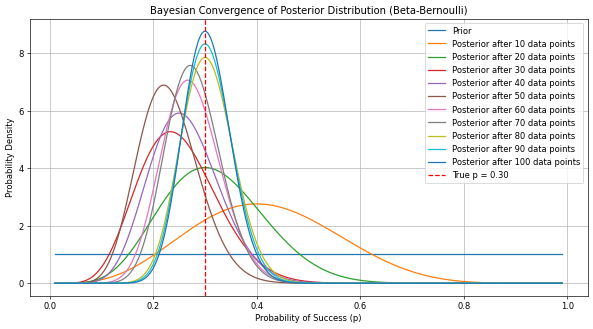

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Simulation Parameters
true_p = 0.3  # The true probability of success
n_observations = 100 # Total number of observations to simulate

# Prior Parameters (Beta distribution)
a_prior = 1  # Alpha parameter
b_prior = 1  # Beta parameter

# Create an array of p values for plotting distributions
p_values = np.linspace(0.01, 0.99, 500)

# Generate Data
np.random.seed(42)  # For reproducibility
observations = np.random.binomial(n=1, p=true_p, size=n_observations)

# Store posterior parameters and distributions at different stages
posterior_states = []

# Initial prior (before any observations)
current_a = a_prior
current_b = b_prior
posterior_states.append({
    'num_data': 0, 'a_post': current_a, 'b_post': current_b,
    'pdf': beta.pdf(p_values, current_a, current_b)
})

# Update posterior with accumulating observations
for i, obs in enumerate(observations):
    if obs == 1:
        current_a += 1
    else:
        current_b += 1

    # Store state at specific intervals or at the end
    if (i + 1) % 10 == 0 or (i + 1) == n_observations:
        posterior_states.append({
            'num_data': i + 1, 'a_post': current_a, 'b_post': current_b,
            'pdf': beta.pdf(p_values, current_a, current_b)
        })

#### Analysis of Convergence

The **Prior** (blue line) represents our initial belief about $p$ before observing any data. In this case, a Beta(1,1) distribution (uniform) implies that all values of $p$ are equally likely initially. As we incorporate more **observations**, the posterior distribution shifts and becomes narrower. This demonstrates that the data is informing our belief about $p$. With a sufficient number of observations, the **posterior distribution becomes highly concentrated around the True $p$ value** (red dashed line). This concentration signifies that the estimator for $p$ becomes more precise as more data is collected.

This simulation confirms the consistency property of Bayesian estimators: as the sample size ($n$) increases, the posterior distribution converges to a point mass at the true parameter value.

### (b) Uniform Likelihood with Improper Uniform Prior

**Given** 1.Prior Distribution: $\pi(\theta) = 1$, for every $\theta > 0$. 2.Likelihood Function: Conditional on $\theta$, $X_1, \dots, X_n \stackrel{\text{iid}}{\sim} U([0, \theta])$.

**Bayesian approach to finding the posterior**

The likelihood for $X_1, \dots, X_n \stackrel{\text{iid}}{\sim} U([0, \theta])$ is $L_n(X_1, \dots, X_n | \theta) = \prod_{i=1}^n \frac{1}{\theta} \mathbf{1}_{0 \le X_i \le \theta} = \theta^{-n} \mathbf{1}_{0 \le \min(X_i) \text{ and } \max(X_i) \le \theta}$.

Since $X_i > 0$ by definition of $U([0, \theta])$, the condition simplifies to $\mathbf{1}_{\max(X_i) \le \theta}$. Let $X_{(n)} = \max(X_i)$. So, $L_n(X_1, \dots, X_n | \theta) = \theta^{-n} \mathbf{1}_{X_{(n)} \le \theta}$. Using Bayes' Theorem, the posterior distribution is
$\pi(\theta | X_1, \dots, X_n) \propto 1 \cdot \theta^{-n} \mathbf{1}_{X_{(n)} \le \theta} = \theta^{-n} \mathbf{1}_{X_{(n)} \le \theta}$. To find the normalizing constant, we integrate the proportional form from $X_{(n)}$ to $\infty$ (since $\theta > 0$)
$\int_{X_{(n)}}^{\infty} \theta^{-n} d\theta = \left[ \frac{\theta^{-n+1}}{-n+1} \right]_{X_{(n)}}^{\infty} = \frac{1}{1-n} [\theta^{1-n}]_{X_{(n)}}^{\infty}$. For the integral to converge, we must have $1-n < 0$, which means $n > 1$. Assuming $n > 1$ $= \frac{1}{1-n} (0 - X_{(n)}^{1-n}) = \frac{X_{(n)}^{1-n}}{n-1}$. So, the normalizing constant is $C = \left(\frac{X_{(n)}^{1-n}}{n-1}\right)^{-1} = (n-1)X_{(n)}^{n-1}$. Thus, the posterior distribution is
- $\pi(\theta | X_1, \dots, X_n) = (n-1)X_{(n)}^{n-1} \theta^{-n} \mathbf{1}_{X_{(n)} \le \theta}$

#### Bayesian Estimator

$\hat{\theta}_{Bayes} = E[\theta | X_1, \dots, X_n] = \int_{X_{(n)}}^{\infty} \theta \cdot \pi(\theta | X_1, \dots, X_n) d\theta = \int_{X_{(n)}}^{\infty} \theta \cdot (n-1)X_{(n)}^{n-1} \theta^{-n} d\theta = (n-1)X_{(n)}^{n-1} \int_{X_{(n)}}^{\infty} \theta^{-n+1} d\theta$

Assuming $n > 2$ for convergence of this integral

$\hat{\theta}_{Bayes} = (n-1)X_{(n)}^{n-1} \left[ \frac{\theta^{-n+2}}{-n+2} \right]_{X_{(n)}}^{\infty} = (n-1)X_{(n)}^{n-1} \left( \frac{0 - X_{(n)}^{2-n}}{2-n} \right) = (n-1)X_{(n)}^{n-1} \left( \frac{X_{(n)}^{2-n}}{n-2} \right) = \frac{n-1}{n-2} X_{(n)}$, where $X_{(n)} = \max(X_1, \dots, X_n)$.

#### Properties of the Bayesian Estimator

**Consistency**: The MLE for $\theta$ in this case is $\hat{\theta}_{MLE} = X_{(n)}$. We know that $X_{(n)} \xrightarrow{p} \theta$ (consistency of the MLE). The Bayesian estimator is $\hat{\theta}_{Bayes} = \frac{n-1}{n-2} X_{(n)}$. As $n \to \infty$, $\frac{n-1}{n-2} \to 1$. Therefore, $\hat{\theta}_{Bayes} \xrightarrow{p} 1 \cdot \theta = \theta$. The Bayesian estimator is **consistent**.

**Asymptotic Normality**: The Bayesian estimator $\hat{\theta}_{Bayes}$ is not asymptotically normal in the usual sense. The behavior of the maximum order statistic $X_{(n)}$ (and thus $\hat{\theta}_{Bayes}$) for a uniform distribution is not captured by the Central Limit Theorem. Instead, its asymptotic distribution is related to extreme value theory, typically showing a different type of convergence (e.g., Weibull distribution for the normalized maximum) rather than normal.

#### Simulate Consistency of Bayesian Estimator for Uniform Distribution

This script demonstrates the consistency of the Bayesian estimator $\hat{\theta}_{Bayes} = \frac{n-1}{n-2} X_{(n)}$ for the parameter $\theta$ of a Uniform distribution $U([0, \theta])$. We simulate data for increasing sample sizes and observe how the estimator converges to the true $\theta$.

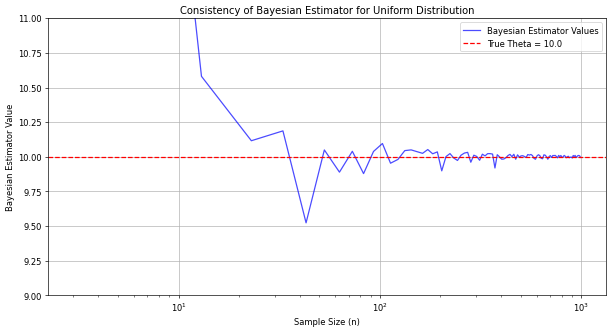

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation Parameters
true_theta = 10.0  # The true value of theta
sample_sizes = np.arange(3, 1000, 10) # Sample sizes from 3 up to 1000 (n must be > 2)

# Store estimator values
bayesian_estimators = []

# Run Simulation
np.random.seed(42) # For reproducibility

for n in sample_sizes:
    # Generate n observations from U([0, true_theta])
    observations = np.random.uniform(low=0, high=true_theta, size=n)

    # Find the maximum observation X_(n)
    max_observation = np.max(observations)

    # Calculate the Bayesian estimator
    # theta_hat_Bayes = (n - 1) / (n - 2) * X_(n)
    if n > 2: # Estimator is defined for n > 2
        bayes_estimator = (n - 1) / (n - 2) * max_observation
    else:
        bayes_estimator = np.nan # Not defined for n <= 2

    bayesian_estimators.append(bayes_estimator)

#### Analysis of Consistency Simulation

The plot above demonstrates the consistency of the Bayesian estimator $\hat{\theta}_{Bayes} = \frac{n-1}{n-2} X_{(n)}$ for the parameter $\theta$ of a Uniform distribution.

**Convergence to True Value**: As the sample size ($n$) increases, the values of the Bayesian estimator (blue line) tend to get closer and closer to the True $\theta$ (red dashed line). **Initial Fluctuations**: For smaller sample sizes (especially just above $n=2$ where the estimator is defined), there might be more fluctuation. This is expected as less data provides less information to precisely estimate the parameter. **Decreasing Bias/Variance**: The estimator approaches the true value, indicating its consistency. Although the theoretical derivation showed a small bias that disappears asymptotically, and the variance also decreases with $n$, leading to the estimator concentrating around $\theta$.

This simulation confirms that as we collect more data, our Bayesian estimator provides a more accurate estimate of the true parameter $\theta$, thus exhibiting the property of consistency.

### (c): Properties of the Bayesian Estimator for Exponential-Exponential Conjugacy

**Recap:**
From Problem Set 4 (a) (which is equivalent to Problem 1 (a) in the notebook), with an Exponential prior $\lambda \sim \text{Exp}(\alpha)$ and Exponential likelihood $X_i \sim \text{Exp}(\lambda)$, the posterior distribution for $\lambda$ is $\text{Gamma}(n+1, \alpha + S_n)$, where $S_n = \sum_{i=1}^n X_i$.

The Bayesian estimator (posterior mean) for $\lambda$ is $\hat{\lambda}_{Bayes} = E[\lambda | X_1, \dots, X_n] = \frac{n+1}{\alpha + S_n}$. Let $S_n = n \bar{X}_n$. Substituting this $\hat{\lambda}_{Bayes} = \frac{n+1}{\alpha + n \bar{X}_n} = \frac{(n+1)/n}{(\alpha + n \bar{X}_n)/n} = \frac{1 + 1/n}{\alpha/n + \bar{X}_n}$.

Properties of the Bayesian Estimator $\hat{\lambda}_{Bayes}$

**Consistency**
As $n \to \infty$
$\lim_{n \to \infty} \hat{\lambda}_{Bayes} = \lim_{n \to \infty} \frac{1 + 1/n}{\alpha/n + \bar{X}_n}$
By the Law of Large Numbers, for $X_i \sim \text{Exp}(\lambda)$, $\bar{X}_n \xrightarrow{p} E[X_i] = 1/\lambda$.
Thus, $\lim_{n \to \infty} \hat{\lambda}_{Bayes} = \frac{1 + 0}{0 + 1/\lambda} = \lambda$.
Therefore, the Bayesian estimator $\hat{\lambda}_{Bayes}$ is **consistent**.

**Asymptotic Normality**
For $X_i \sim \text{Exp}(\lambda)$, we know $E[X_i] = 1/\lambda$ and $Var(X_i) = 1/\lambda^2$.
By the Central Limit Theorem, $\sqrt{n}(\bar{X}_n - 1/\lambda) \xrightarrow{d} N(0, 1/\lambda^2)$. We can approximate $\hat{\lambda}_{Bayes} \approx 1/\bar{X}_n$ for large $n$. Let $g(x) = 1/x$. Using the Delta Method:
If $\sqrt{n}(\bar{X}_n - E[X_i]) \xrightarrow{d} N(0, Var(X_i))$, then $\sqrt{n}(g(\bar{X}_n) - g(E[X_i])) \xrightarrow{d} N(0, (g'(E[X_i]))^2 Var(X_i))$. Here, $g(x) = 1/x$, so $g'(x) = -1/x^2$.
$E[X_i] = 1/\lambda$. $g'(E[X_i]) = g'(1/\lambda) = -1/(1/\lambda)^2 = -\lambda^2$. The asymptotic variance is $(g'(E[X_i]))^2 Var(X_i) = (-\lambda^2)^2 \cdot (1/\lambda^2) = \lambda^4 \cdot (1/\lambda^2) = \lambda^2$. Therefore, $\sqrt{n}(\hat{\lambda}_{Bayes} - \lambda) \xrightarrow{d} N(0, \lambda^2)$, which confirms that the Bayesian estimator $\hat{\lambda}_{Bayes}$ is **asymptotically normal** with **asymptotic variance $\lambda^2$**.

#### Simulate Bayesian Convergence (Exponential-Exponential Example)

We simulate the Bayesian inference process for the Exponential likelihood with an Exponential prior. The goal is to observe how the posterior distribution for the parameter $\lambda$ converges towards the true value of $\lambda$ as we collect more data, illustrating its consistency and asymptotic normality.

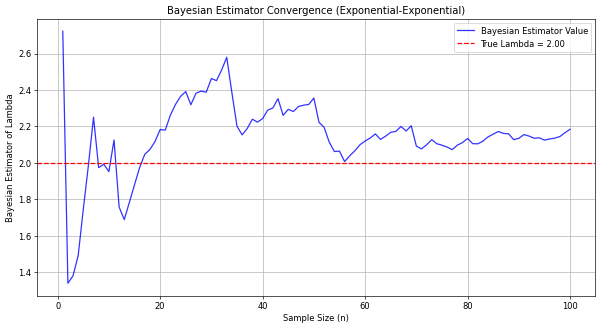

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

# Simulation Parameters
true_lambda = 2.0  # The true rate parameter
n_observations = 100 # Total number of observations to simulate

# Prior Parameters (Exponential distribution, which is Gamma(1, rate))
alpha_prior = 0.5  # Rate parameter for Exponential prior

# Generate Data
np.random.seed(42)  # For reproducibility
# scipy.stats.expon uses scale=1/rate
observations = expon.rvs(scale=1/true_lambda, size=n_observations)

# Store Bayesian estimator values at different stages
bayesian_estimator_trace = []

# Update posterior with accumulating observations
sum_x = 0
for i, obs in enumerate(observations):
    n = i + 1 # Current sample size
    sum_x += obs

    # Posterior parameters (Gamma(k_post, beta_post))
    # k_post = n + k_prior = n + 1 (since Exponential prior is Gamma(1, alpha_prior))
    k_post = n + 1
    # beta_post = sum_X + beta_prior = sum_x + alpha_prior
    beta_post = sum_x + alpha_prior

    # Calculate Bayesian Estimator (posterior mean for Gamma(k, beta) is k/beta)
    lambda_hat_bayes = k_post / beta_post

    # Store sample size and estimator value
    bayesian_estimator_trace.append({
        'n': n,
        'estimator_value': lambda_hat_bayes
    })

# Extract n and estimator values for plotting
sample_sizes_plot = [item['n'] for item in bayesian_estimator_trace]
estimator_values_plot = [item['estimator_value'] for item in bayesian_estimator_trace]

#### Analysis of Exponential-Exponential Convergence Simulation

The plot above demonstrates the convergence of the posterior distribution for the rate parameter $\lambda$ in the Exponential-Exponential conjugacy case.

The **Prior (Exponential)** (blue line) represents our initial belief about $\lambda$ before observing any data. As we incorporate more **observations**, the posterior distribution shifts towards the true $\lambda$ and becomes significantly narrower. This visualizes how the data refines our uncertainty and provides a more precise estimate. With a sufficient number of observations, the **posterior distribution becomes highly concentrated around the True $\lambda$ value** (red dashed line). This concentration illustrates the **consistency** of the Bayesian estimator – as $n \to \infty$, the posterior converges to a point mass at the true parameter value.

The narrowing of the posterior also hints at the **asymptotic normality**; as the posterior becomes concentrated, its shape approaches that of a normal distribution centered at the true value, with its variance decreasing as $n$ increases, consistent with the derived asymptotic variance.

### (d): Poisson Likelihood with Exponential Prior

**Given:** 1. **Prior Distribution**: $\lambda \sim \text{Exp}(\alpha)$ for some $\alpha > 0$. The PDF is $\pi(\lambda) = \alpha e^{-\alpha\lambda}$ for $\lambda \ge 0$. For proportionality, we write: $\pi(\lambda) \propto e^{-\alpha\lambda}$.
2. **Likelihood Function**: Conditional on $\lambda$, $X_1, \dots, X_n \stackrel{\text{iid}}{\sim} \text{Poiss}(\lambda)$. The PMF for a single observation $X_i$ is $P(X_i=x_i|\lambda) = \frac{\lambda^{x_i} e^{-\lambda}}{x_i!}$. For $n$ observations, the joint likelihood is $L(X_1, \dots, X_n | \lambda) = \prod_{i=1}^n \frac{\lambda^{x_i} e^{-\lambda}}{x_i!} = \frac{\lambda^{\sum x_i} e^{-n\lambda}}{\prod x_i!}$. Let $S_n = \sum_{i=1}^n X_i$. For proportionality, we write $L(X_1, \dots, X_n | \lambda) \propto \lambda^{S_n} e^{-n\lambda}$.


#### Deriving the Posterior

Using Bayes' Theorem $\pi(\lambda | X_1, \dots, X_n) \propto (\lambda^{S_n} e^{-n\lambda}) \cdot (e^{-\alpha\lambda})$. Combining terms with the same base $\pi(\lambda | X_1, \dots, X_n) \propto \lambda^{S_n} e^{-(n+\alpha)\lambda}$.

This form is the kernel of a **Gamma distribution**. The standard parameterization of the Gamma distribution (with shape $k$ and rate $\beta$) has a PDF proportional to $x^{k-1} e^{-\beta x}$. Comparing our derived posterior kernel $\lambda^{S_n} e^{-(n+\alpha)\lambda}$ with the Gamma PDF kernel $x^{k-1} e^{-\beta x}$, **Shape parameter ($k_{posterior}$)**: $k_{posterior} - 1 = S_n \implies k_{posterior} = S_n + 1$, and **Rate parameter ($eta_{posterior}$)**: $\beta_{posterior} = n + \alpha$. Thus, the posterior distribution for $\lambda$ is
- $\text{Gamma}(k_{posterior} = S_n + 1, \beta_{posterior} = n + \alpha)$.

#### Bayesian Estimator
The Bayesian estimator, typically the posterior mean for a Gamma distribution $\text{Gamma}(k, \beta)$, is given by $E[\lambda] = \frac{k}{\beta}$. Substituting the posterior parameters $\hat{\lambda}_{Bayes} = \frac{S_n + 1}{n + \alpha}$. Let $\bar{X}_n = \frac{S_n}{n}$. We can rewrite the estimator as
- $\hat{\lambda}_{Bayes} = \frac{(S_n/n) + (1/n)}{(n/n) + (\alpha/n)} = \frac{\bar{X}_n + 1/n}{1 + \alpha/n}$

This derived estimator matches the form you provided.

Properties of the Bayesian Estimator  

**Consistency:** As $n \to \infty$: $\lim_{n \to \infty} \hat{\lambda}_{Bayes} = \lim_{n \to \infty} \frac{\bar{X}_n + 1/n}{1 + \alpha/n}$

By the LLN, for $X_i \sim \text{Poiss}(\lambda)$, $\bar{X}_n \xrightarrow{p} E[X_i] = \lambda$. Thus, $\lim_{n \to \infty} \hat{\lambda}_{Bayes} = \frac{\lambda + 0}{1 + 0} = \lambda$. Therefore, the Bayesian estimator $\hat{\lambda}_{Bayes}$ is **consistent**.

**Asymptotic Normality:** For $X_i \sim \text{Poiss}(\lambda)$, we know $E[X_i] = \lambda$ and $Var(X_i) = \lambda$. By the CLT, $\sqrt{n}(\bar{X}_n - \lambda) \xrightarrow{d} N(0, \lambda)$.

Our estimator is $\hat{\lambda}_{Bayes} = \frac{\bar{X}_n + 1/n}{1 + \alpha/n}$. For large $n$, this estimator is asymptotically equivalent to $\bar{X}_n$ since $1/n \to 0$ and $\alpha/n \to 0$.

More rigorously, using the Delta Method, let $g(x) = \frac{x + 1/n}{1 + \alpha/n}$. As $n \to \infty$, the limiting function is $g(x) = x$, and thus $g'(x) = 1$.

Applying the Delta Method: $\sqrt{n}(\hat{\lambda}_{Bayes} - \lambda) \xrightarrow{d} N(0, (g'(\lambda))^2 Var(X_i))$. As $n \to \infty$, $g'(\lambda) \to 1$. So, the asymptotic variance is $1^2 \cdot \lambda = \lambda$.
Therefore, $\sqrt{n}(\hat{\lambda}_{Bayes} - \lambda) \xrightarrow{d} N(0, \lambda)$, which confirms that the Bayesian estimator $\hat{\lambda}_{Bayes}$ is **asymptotically normal** with **asymptotic variance $\lambda$**.

### Simulate Bayesian Estimator Convergence (Poisson-Exponential Example)

We will simulate the Bayesian inference process for the Poisson likelihood with an Exponential prior. The goal is to observe how the Bayesian estimator for the parameter $\lambda$ converges towards the true value of $\lambda$ as we collect more data, illustrating its consistency and asymptotic normality.

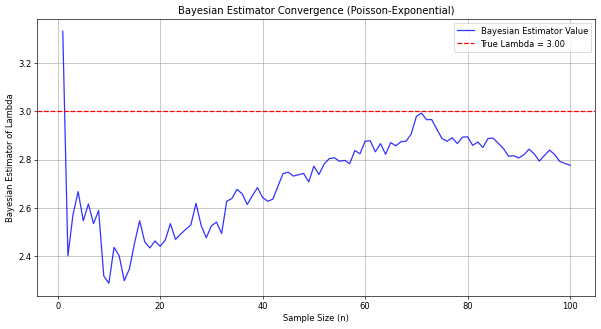

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Simulation Parameters
true_lambda = 3.0  # The true rate parameter for the Poisson distribution
n_observations = 100 # Total number of observations to simulate

# Prior Parameters (Exponential distribution)
alpha_prior = 0.5  # Rate parameter for Exponential prior

# Generate Data
np.random.seed(42)  # For reproducibility
observations = poisson.rvs(mu=true_lambda, size=n_observations)

# Store Bayesian estimator values at different stages
bayesian_estimator_trace_poisson = []

# Update posterior with accumulating observations
sum_x = 0
for i, obs in enumerate(observations):
    n = i + 1 # Current sample size
    sum_x += obs

    # Calculate Bayesian Estimator
    # lambda_hat_Bayes = (S_n + 1) / (n + alpha_prior)
    lambda_hat_bayes = (sum_x + 1) / (n + alpha_prior)

    # Store sample size and estimator value
    bayesian_estimator_trace_poisson.append({
        'n': n,
        'estimator_value': lambda_hat_bayes
    })

# Extract n and estimator values for plotting
sample_sizes_plot = [item['n'] for item in bayesian_estimator_trace_poisson]
estimator_values_plot = [item['estimator_value'] for item in bayesian_estimator_trace_poisson]

#### Analysis of Poisson-Exponential Convergence Simulation

The plot above demonstrates the convergence of the Bayesian estimator for the rate parameter $\lambda$ in the Poisson-Exponential conjugacy case
- The **Bayesian Estimator Value** (blue line) for $\lambda$ shows initial fluctuations, particularly with smaller sample sizes, as the amount of data available to inform the estimator is limited.
- As the **Sample Size (n)** increases, the estimator's value quickly stabilizes and converges towards the `True Lambda` value of 3.0 (red dashed line).

This simulation visually confirms the **consistency** of the Bayesian estimator: with more observations, the estimator becomes increasingly precise and accurately approximates the true parameter value. The convergence also indirectly supports the **asymptotic normality** of the estimator, as the estimator's sampling distribution would narrow around the true value, eventually resembling a normal distribution.